In [1]:
targetDirectory = "/home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01"
resolverFilter = None

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
from datetime import datetime
import json
import os

In [3]:
data = []


In [4]:
def processDir(path: str, filter = None):
    scanStats = {}
    with open(path+"/scan_metadata.json", "r") as file:
        t = json.load(file)["Start"]
        scanStats["time"] = datetime.fromisoformat(t).replace(second=0, microsecond=0)
    
    resolver = pd.read_parquet(path+"/test1.parquet")
    if filter is None:
        tmp = resolver.groupby("qmin_enabled").agg(total=("qmin_enabled", "count"))
    else:
        tmp = resolver[resolver["resolver_type"] == filter].groupby("qmin_enabled").agg(total=("qmin_enabled", "count"))

    if -1 in tmp.index:
        scanStats["error_total"] = tmp.loc[-1, "total"]
    else:
        scanStats["error_total"] = 0
    if 0 in tmp.index:
        scanStats["no_qmin_total"] = tmp.loc[0, "total"]
    else:
        scanStats["no_qmin_total"] = 0
    if 1 in tmp.index:
        scanStats["qmin_total"] = tmp.loc[1, "total"]
    else:
        scanStats["qmin_total"] = 0
    if 2 in tmp.index:
        scanStats["both_total"] = tmp.loc[2, "total"]
    else:
        scanStats["both_total"] = 0
    
    tmp = resolver[resolver["qmin_enabled"] >= 1]
    if filter is None:
        tmp = tmp.groupby("induction_qmin").agg(total=("induction_qmin", "count"))
    else:
        tmp = tmp[tmp["resolver_type"] == filter].groupby("induction_qmin").agg(total=("induction_qmin", "count"))

    if -1 in tmp.index:
        scanStats["induction_error_total"] = tmp.loc[-1, "total"]
    else:
        scanStats["induction_error_total"] = 0
    if 0 in tmp.index:
        scanStats["induction_no_qmin_total"] = tmp.loc[0, "total"]
    else:
        scanStats["induction_no_qmin_total"] = 0
    if 1 in tmp.index:
        scanStats["induction_qmin_total"] = tmp.loc[1, "total"]
    else:
        scanStats["induction_qmin_total"] = 0
    if 2 in tmp.index:
        scanStats["induction_both_total"] = tmp.loc[2, "total"]
    else:
        scanStats["induction_both_total"] = 0

    tmp = resolver[resolver["qmin_enabled"] >= 1]
    if filter is None:
        tmp = tmp.groupby("nx_optimization").agg(total=("nx_optimization", "count"))
    else:
        tmp = tmp[tmp["resolver_type"] == filter].groupby("nx_optimization").agg(total=("nx_optimization", "count"))

    if -1 in tmp.index:
        scanStats["nx_error_total"] = tmp.loc[-1, "total"]
    else:
        scanStats["nx_error_total"] = 0
    if 0 in tmp.index:
        scanStats["nx_no_qmin_total"] = tmp.loc[0, "total"]
    else:
        scanStats["nx_no_qmin_total"] = 0
    if 1 in tmp.index:
        scanStats["nx_qmin_total"] = tmp.loc[1, "total"]
    else:
        scanStats["nx_qmin_total"] = 0
    if 2 in tmp.index:
        scanStats["nx_both_total"] = tmp.loc[2, "total"]
    else:
        scanStats["nx_both_total"] = 0
    


    return scanStats

In [5]:
def checkSubDir(dir: os.DirEntry):
    if not dir.is_dir():
        return False
    if not os.path.isfile(dir.path + "/scan_metadata.json"):
        return False
    if not os.path.isfile(dir.path + "/test1.parquet"):
        return False
    if not os.path.isfile(dir.path +"/test2.parquet"):
        return False
    return True

def getValidSubDirectories(rootDir):
    dirs = [ f.path for f in os.scandir(targetDirectory) if checkSubDir(f) ]
    return dirs


In [11]:
for dir in getValidSubDirectories(targetDirectory):
    print("now scanning:", dir)
    data.append(processDir(dir, resolverFilter))

df = pd.DataFrame(data)
df_sorted = df.copy()
df_sorted["time"] = pd.to_datetime(df_sorted["time"])
df_sorted = df_sorted.sort_values("time").reset_index(drop=True)
df_sorted.head()

now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-24_01-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-29_13-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-28_01-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-24_13-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-25_13-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-30_01-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/2026-08-30_22-01/2026-08-30_13-00
now scanning: /home/Til/Documents/Uni/bachelors/odns-measurement-tools/src/data/processed/qmin/20

,time,error_total,no_qmin_total,qmin_total,both_total,induction_error_total,induction_no_qmin_total,induction_qmin_total,induction_both_total,nx_error_total,nx_no_qmin_total,nx_qmin_total,nx_both_total
0,2026-08-23 01:00:00+02:00,756542,393068,228908,46261,14228,25022,198278,37641,20440,222620,8096,24013
1,2026-08-23 01:00:00+02:00,756542,393068,228908,46261,14228,25022,198278,37641,20440,222620,8096,24013
2,2026-08-23 13:00:00+02:00,757979,388176,231701,46923,14782,26253,199391,38198,20800,222794,8693,26337
3,2026-08-23 13:00:00+02:00,757979,388176,231701,46923,14782,26253,199391,38198,20800,222794,8693,26337
4,2026-08-24 01:00:00+02:00,761888,390696,227609,44586,14104,24172,197452,36467,20479,219476,7946,24294


In [7]:
def plotData(input_frame: pd.DataFrame, colums: list):
    perc = input_frame[colums].div(input_frame[colums].sum(axis=1), axis=0) * 100

    x = mdates.date2num(input_frame["time"].dt.to_pydatetime())

    bottom = pd.Series(0.0, index=df.index)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.stackplot(
        input_frame["time"].to_numpy(),
        *[perc[col].to_numpy() for col in colums],
        labels=colums,
        alpha=0.9
    )

    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])


    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

    # Legend
    ax.legend(
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()



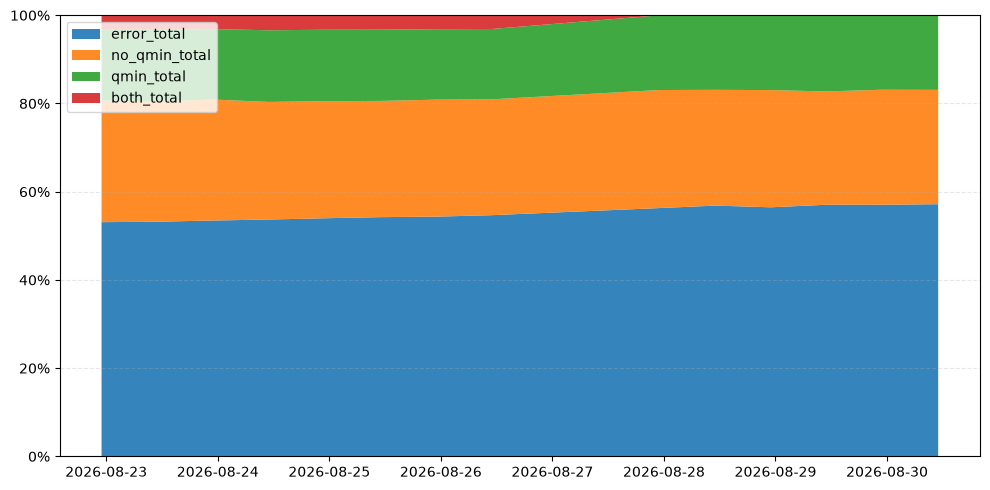

,time,error_total,no_qmin_total,qmin_total,both_total,induction_error_total,induction_no_qmin_total,induction_qmin_total,induction_both_total,nx_error_total,nx_no_qmin_total,nx_qmin_total,nx_both_total
0,2026-08-23 01:00:00+02:00,756542,393068,228908,46261,14228,25022,198278,37641,20440,222620,8096,24013
1,2026-08-23 01:00:00+02:00,756542,393068,228908,46261,14228,25022,198278,37641,20440,222620,8096,24013
2,2026-08-23 13:00:00+02:00,757979,388176,231701,46923,14782,26253,199391,38198,20800,222794,8693,26337
3,2026-08-23 13:00:00+02:00,757979,388176,231701,46923,14782,26253,199391,38198,20800,222794,8693,26337
4,2026-08-24 01:00:00+02:00,761888,390696,227609,44586,14104,24172,197452,36467,20479,219476,7946,24294
5,2026-08-24 01:00:00+02:00,761888,390696,227609,44586,14104,24172,197452,36467,20479,219476,7946,24294
6,2026-08-24 13:00:00+02:00,765028,379898,231419,48434,14658,27025,199297,38873,21178,222588,8867,27220
7,2026-08-24 13:00:00+02:00,765028,379898,231419,48434,14658,27025,199297,38873,21178,222588,8867,27220
8,2026-08-25 01:00:00+02:00,769218,378125,230707,46729,13913,25402,199621,38500,20628,223993,8038,24777
9,2026-08-25 01:00:00+02:00,769218,378125,230707,46729,13913,25402,199621,38500,20628,223993,8038,24777


In [14]:
cols = ["error_total", "no_qmin_total", "qmin_total", "both_total"]
plotData(df_sorted, cols)
df_sorted.head(22)

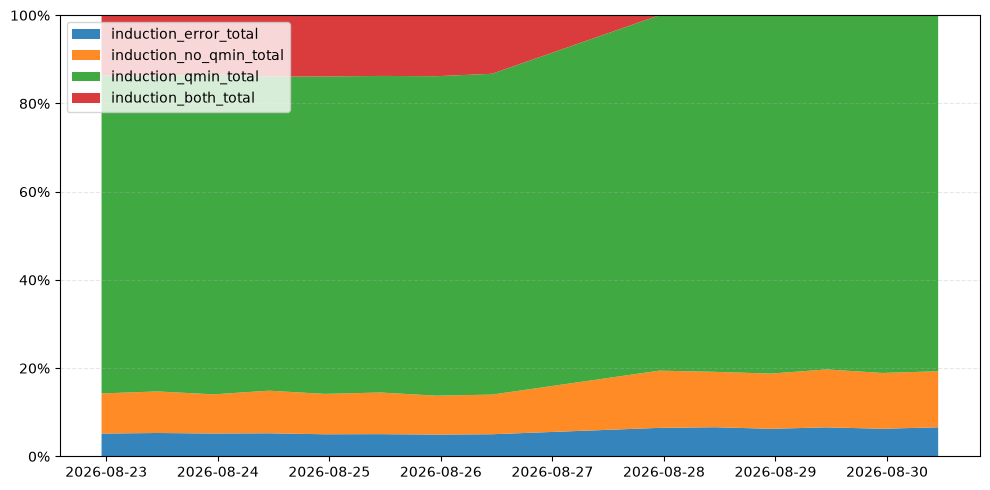

In [9]:
cols = ["induction_error_total", "induction_no_qmin_total", "induction_qmin_total", "induction_both_total"]
plotData(df_sorted, cols)

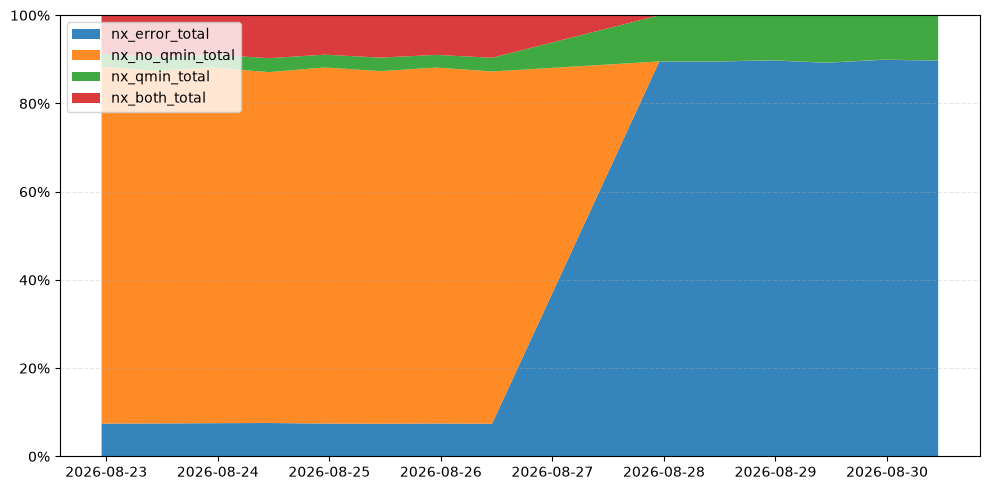

In [10]:
cols = ["nx_error_total", "nx_no_qmin_total", "nx_qmin_total", "nx_both_total"]
plotData(df_sorted, cols)